In [1]:
import pandas as pd
import numpy as np
import pandas_ta as ta
pd.options.display.float_format = '{:.2f}'.format
pd.options.display.max_columns = None

from datetime import datetime, date
from dateutil.relativedelta import relativedelta
import time
import random

import yfinance as yf
import requests
from fredapi import Fred

from statsmodels.tsa.seasonal import STL
from sktime.utils.plotting import plot_correlations
from scipy.stats import randint, uniform, loguniform
from scipy.special import boxcox, inv_boxcox

import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
plt.rcParams['figure.figsize'] = (18, 9)
plt.rcParams["figure.autolayout"] = True

from get_data import DataMaker  # самодельная библиотека для сбора датасетов
from ml_models import *

import shap

from sklearn.ensemble import RandomForestRegressor, StackingRegressor
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer, TransformedTargetRegressor
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split, RandomizedSearchCV, GridSearchCV, TimeSeriesSplit
from sklearn.preprocessing import RobustScaler, StandardScaler
from sklearn.linear_model import Ridge, Lasso, ElasticNet
from sklearn.metrics import r2_score, make_scorer, mean_absolute_error
from sklearn.neighbors import KNeighborsRegressor
from sklearn.decomposition import PCA
from sklearn.exceptions import ConvergenceWarning

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Flatten, LSTM, GRU, Conv1D, MaxPooling1D
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from tensorflow.keras import backend as K

from sklearn.exceptions import ConvergenceWarning
import warnings
warnings.filterwarnings('ignore', category=ConvergenceWarning)
warnings.filterwarnings('ignore')

2025-05-09 22:01:48.524732: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1746817308.541668    3847 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1746817308.546869    3847 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-05-09 22:01:48.564718: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [29]:
df = pd.read_csv('new_hour.csv', parse_dates=['Datetime'], index_col=['Datetime'])
df

,AMD,ARKK_ETF,ARK_NextGen_Internet_ETF,AUD/USD,Adobe,Amazon,Apple,BTC,Bitcoin_Cash,Brent_Oil,Cardano,Chainlink,Copper,Dogecoin,Dow_Jones,ETH,EUR/USD,Ethereum_Classic,GBP/USD,Gold,Google,Intel,Invesco_QQQ,Litecoin,Marathon_Digital,Meta,MicroStrategy,Microsoft,NASDAQ_100,NVIDIA,Natural_Gas,Platinum,Riot_Blockchain,S&P_500,SPDR_Consumer_Discretionary,SPDR_Energy,SPDR_Financials,SPDR_HealthCare,SPDR_Industrials,SPDR_Materials,SPDR_RealEstate,SPDR_Tech,Silver,Stellar,TRON,Tesla,Tether,USD/CAD,USD/CHF,USD/JPY,VIX,VanEck_Semiconductor_ETF,WTI,XRP,iShares_Semiconductor_ETF,RSI,MACD,ATR,OBV,day,minute,hour,BTC_lag1,BTC_lag2,BTC_lag5,BTC_lag10,BTC_mean5,BTC_std10,SMA_50,EMA_100,TEMA_20,KAMA_20,HMA_10
Datetime,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2023-05-12 04:00:00,97.16,38.85,50.07,0.67,341.25,112.27,173.82,26645.40,114.29,74.59,0.36,6.30,3.71,0.07,33294.53,1766.75,1.09,18.01,1.25,2016.65,116.68,28.89,326.15,78.92,8.75,236.13,28.69,310.07,13386.80,28.57,2.17,1096.32,10.67,4128.96,149.05,78.34,32.02,132.30,98.38,77.93,37.01,151.09,24.19,0.09,0.07,171.76,1.00,1.35,1.12,0.01,16.91,123.00,70.57,0.43,136.97,33.01,-170.80,192.17,-4549473280.00,12,0,4,26607.26,26683.53,26979.04,26892.10,26777.07,159.58,27434.55,27592.64,26689.15,25979.54,26753.13
2023-05-12 05:00:00,97.16,38.85,50.07,0.67,341.25,112.27,173.82,26392.60,113.70,74.71,0.36,6.28,3.71,0.07,33294.53,1753.56,1.09,17.95,1.25,2015.05,116.68,28.89,326.15,78.65,8.75,236.13,28.69,310.07,13386.80,28.57,2.17,1095.48,10.67,4128.96,149.05,78.34,32.02,132.30,98.38,77.93,37.01,151.09,24.17,0.09,0.07,171.76,1.00,1.35,1.12,0.01,16.91,123.00,70.66,0.43,136.97,25.43,-199.58,209.06,-5159203840.00,12,0,5,26645.40,26607.26,27025.97,26892.10,26650.40,218.74,27414.20,27574.06,26645.88,26044.13,26645.84
2023-05-12 06:00:00,97.16,38.85,50.07,0.67,341.25,112.27,173.82,26267.62,114.06,74.37,0.36,6.32,3.71,0.07,33294.53,1753.68,1.09,18.00,1.25,2014.20,116.68,28.89,326.15,78.75,8.75,236.13,28.69,310.07,13386.80,28.57,2.16,1095.95,10.67,4128.96,149.05,78.34,32.02,132.30,98.38,77.93,37.01,151.09,24.14,0.09,0.07,171.76,1.00,1.35,1.12,0.01,16.91,123.00,70.36,0.43,136.97,24.85,-222.34,205.46,-5974914048.00,12,0,6,26392.60,26645.40,26923.20,26971.94,26519.28,271.13,27386.03,27548.37,26515.46,26078.14,26489.57
2023-05-12 07:00:00,97.16,38.85,50.07,0.67,341.25,112.27,173.82,26320.54,114.39,74.50,0.36,6.37,3.72,0.07,33294.53,1759.66,1.09,18.05,1.25,2014.65,116.68,28.89,326.15,79.09,8.75,236.13,28.69,310.07,13386.80,28.57,2.16,1101.38,10.67,4128.96,149.05,78.34,32.02,132.30,98.38,77.93,37.01,151.09,24.17,0.09,0.07,171.76,1.00,1.35,1.12,0.01,16.71,123.00,70.47,0.43,136.97,26.20,-235.79,196.59,-5594864640.00,12,0,7,26267.62,26392.60,26683.53,26997.94,26446.68,286.11,27358.23,27523.64,26417.90,26111.97,26347.07
2023-05-12 08:00:00,97.16,38.85,50.07,0.67,341.25,112.27,173.82,26310.25,114.33,74.52,0.36,6.39,3.72,0.07,33294.53,1760.66,1.09,18.05,1.25,2012.00,116.68,28.89,326.15,79.01,8.75,236.13,28.69,310.07,13386.80,28.57,2.16,1105.12,10.67,4128.96,149.05,78.34,32.02,132.30,98.38,77.93,37.01,151.09,24.10,0.09,0.07,171.76,1.00,1.35,1.12,0.01,16.56,123.00,70.50,0.43,136.97,25.91,-244.72,191.79,-5594864640.00,12,0,8,26320.54,26267.62,26607.26,26963.07,26387.28,289.02,27331.35,27499.64,26344.71,26140.54,26249.17
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-05-04 17:00:00,98.75,51.89,104.71,0.64,380.87,190.10,205.00,95408.81,355.27,61.48,0.68,14.07,4.67,0.17,41315.60,1828.32,1.13,16.12,1.33,3246.12,163.96,20.59,488.84,86.33,14.51,597.45,394.90,435.19,20096.61,114.33,3.66,966.92,8.39,5686.26,201.38,82.02,49.81,138.52,134.72,84.95,41.95,216.48,32.20,0.27,0.25,287.52,1.00,1.38,1.21,0.01,22.67,219.10,58.43,2.18,190.06,39.01,-229.59,243.85,4949504

In [26]:
df_hour = pd.read_csv('new_hour.csv', parse_dates=['Datetime'], index_col=['Datetime'])


X_hour, y_hour = df_hour.drop(columns=['BTC']), df_hour['BTC']

In [27]:
X_hour

,Apple,Cardano,Adobe,AMD,Amazon,ARKK_ETF,ARK_NextGen_Internet_ETF,AUD/USD,Bitcoin_Cash,Brent_Oil,USD/CHF,WTI,Dogecoin,Ethereum_Classic,ETH,EUR/USD,GBP/USD,Gold,Google,Copper,Intel,USD/JPY,Chainlink,Litecoin,Marathon_Digital,Meta,Microsoft,MicroStrategy,Natural_Gas,NVIDIA,Platinum,Invesco_QQQ,Riot_Blockchain,Silver,VanEck_Semiconductor_ETF,iShares_Semiconductor_ETF,TRON,Tesla,USD/CAD,Tether,SPDR_Materials,SPDR_Energy,SPDR_Financials,SPDR_Industrials,SPDR_Tech,Stellar,SPDR_RealEstate,SPDR_HealthCare,SPDR_Consumer_Discretionary,XRP,Dow_Jones,S&P_500,NASDAQ_100,VIX,RSI,MACD,ATR,OBV,day,hour,BTC_lag1,BTC_lag2,BTC_lag5,BTC_lag10,BTC_mean5,BTC_std10
Datetime,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2023-05-09 19:00:00,171.85,0.36,342.89,95.12,106.57,38.23,49.66,0.68,122.20,77.27,1.12,73.52,0.07,18.82,1844.70,1.10,1.26,2042.82,107.39,3.90,30.11,0.01,6.51,79.56,9.39,233.53,306.87,30.36,2.26,28.58,1115.08,321.59,11.45,25.88,123.07,136.45,0.07,168.99,1.34,1.00,78.75,80.41,32.28,99.38,150.01,0.09,37.07,132.46,147.65,0.42,33579.11,4120.83,13201.80,17.66,47.65,-25.82,162.64,-23447552.00,9,19,27648.51,27591.68,27551.23,27748.24,27553.37,89.80
2023-05-09 20:00:00,171.85,0.36,342.89,95.12,106.57,38.23,49.66,0.68,122.01,77.39,1.12,73.59,0.07,18.83,1849.06,1.10,1.26,2043.43,107.39,3.90,30.11,0.01,6.52,79.76,9.39,233.53,306.87,30.36,2.26,28.58,1115.80,321.59,11.45,25.89,123.07,136.45,0.07,168.99,1.34,1.00,78.75,80.41,32.28,99.38,150.01,0.09,37.07,132.46,147.65,0.42,33579.11,4120.83,13201.80,17.66,55.59,-16.54,162.01,-23447552.00,9,20,27592.72,27648.51,27466.98,27748.24,27588.98,74.88
2023-05-09 21:00:00,171.85,0.36,342.89,95.12,106.57,38.23,49.66,0.68,122.02,77.24,1.12,73.49,0.07,18.80,1850.68,1.10,1.26,2043.55,107.39,3.90,30.11,0.01,6.51,79.69,9.39,233.53,306.87,30.36,2.25,28.58,1119.82,321.59,11.45,25.92,123.07,136.45,0.07,168.99,1.34,1.00,78.75,80.41,32.28,99.38,150.01,0.09,37.07,132.46,147.65,0.43,33579.11,4120.83,13201.80,17.66,53.07,-11.64,160.75,-23447552.00,9,21,27645.01,27592.72,27466.98,27664.32,27630.45,76.12
2023-05-09 22:00:00,171.85,0.36,342.89,95.12,106.57,38.23,49.66,0.68,121.50,77.09,1.12,73.38,0.07,18.76,1845.12,1.10,1.26,2041.05,107.39,3.90,30.11,0.01,6.51,79.72,9.39,233.53,306.87,30.36,2.24,28.58,1119.20,321.59,11.45,25.86,123.07,136.45,0.07,168.99,1.34,1.00,78.75,80.41,32.28,99.38,150.01,0.09,37.07,132.46,147.65,0.43,33579.11,4120.83,13201.80,17.66,50.05,-10.84,151.55,-23447552.00,9,22,27674.33,27645.01,27591.68,27664.32,27636.93,72.45
2023-05-09 23:00:00,171.85,0.36,342.89,95.12,106.57,38.23,49.66,0.68,121.46,76.88,1.12,73.16,0.07,18.68,1844.05,1.10,1.26,2038.88,107.39,3.90,30.11,0.01,6.50,79.71,9.39,233.53,306.87,30.36,2.24,28.58,1117.90,321.59,11.45,25.84,123.07,136.45,0.07,168.99,1.34,1.00,78.75,80.41,32.28,99.38,150.01,0.09,37.07,132.46,147.65,0.43,33579.11,4120.83,13201.80,17.66,48.78,-11.42,143.93,-23447552.00,9,23,27624.09,27674.33,27648.51,27551.23,27625.36,71.71
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-05-06 19:00:00,198.84,0.66,383.40,98.89,185.20,48.87,102.12,0.65,358.54,62.42,1.22,59.40,0.17,15.83,1783.00,1.14,1.34,3403.70,163.42,4.78,19.95,0.01,13.54,83.45,13.16,587.88,433.89,385.76,3.55,113.75,992.73,481.97,7.87,33.34,215.99,186.97,0.25,275.56,1.38,1.00,83.76,80.60,49.21,133.54,213.90,0.26,41.61,134.28,197.57,2.14,40854.34,5611.74,19811.26,24.76,64.75,69.29,478.33,492165189120.00,6,19,94530.47,94389.95,94198.70,93904.98,94557.34,403.72
2025-05-06 20:00:00,198.84,0.66,383.40,98.89,185.20,48.87,102.12,0.65,360.75,62.53,1.22,59.55,0.17,15.90,1788.43,1.14,1.34,3403.92,163.42,4.79,19.95,0.01,13.63,84.28,13.16,587.88,433.89,385.76,3.55,113.75,992.32,481.97,7.87,33.37,215.99,186.97,0.25,275.56,1.38,1.00,83.76,80.60,49.21,133.54,213.90,0.26,41.61,134.28,197.57,2.14,4

In [7]:
rf_hour = StackingForecaster(
    test_size=int(X_hour.shape[0] * 0.2)
)
rf_hour.fit(X_hour, y_hour)

xgb_hour = StackingForecaster(
    test_size=int(X_hour.shape[0] * 0.2),
    model_type='XGBoost',
)
xgb_hour.fit(X_hour, y_hour)

lgbm_hour = StackingForecaster(
    test_size=int(X_hour.shape[0] * 0.2),
    model_type='LightGBM'
)
lgbm_hour.fit(X_hour, y_hour)


[2025-05-09 22:22:25] RandomForest начала обучаться


2025-05-09 22:22:28.301997: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2025-05-09 22:22:28.301997: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2025-05-09 22:22:28.313835: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2025-05-09 22:22:28.324216: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2025-05-09 22:22:28.324276: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for 


[2025-05-09 22:46:19] RandomForest закончила обучаться

[2025-05-09 22:46:20] XGBoost начала обучаться


2025-05-09 22:46:23.568076: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1746819983.596589   11778 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1746819983.605003   11778 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-05-09 22:46:23.633219: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-05-09 22:46:23.742070: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: 


[2025-05-09 22:52:08] XGBoost закончила обучаться

[2025-05-09 22:52:11] LightGBM начала обучаться


2025-05-09 22:52:54.513558: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1746820374.542421   16966 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1746820374.551001   16966 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-05-09 22:52:54.578525: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.



[2025-05-09 22:56:45] LightGBM закончила обучаться


StackingForecaster(model_type='LightGBM', test_size=4191)

In [15]:
X_hour.columns

['Adobe', 'AMD', 'Amazon', 'NVIDIA', 'Platinum', 'Invesco_QQQ']

Index(['Apple', 'Cardano', 'Adobe', 'AMD', 'Amazon', 'ARKK_ETF',
       'ARK_NextGen_Internet_ETF', 'AUD/USD', 'Bitcoin_Cash', 'Brent_Oil',
       'USD/CHF', 'WTI', 'Dogecoin', 'Ethereum_Classic', 'ETH', 'EUR/USD',
       'GBP/USD', 'Gold', 'Google', 'Copper', 'Intel', 'USD/JPY', 'Chainlink',
       'Litecoin', 'Marathon_Digital', 'Meta', 'Microsoft', 'MicroStrategy',
       'Natural_Gas', 'NVIDIA', 'Platinum', 'Invesco_QQQ', 'Riot_Blockchain',
       'Silver', 'VanEck_Semiconductor_ETF', 'iShares_Semiconductor_ETF',
       'TRON', 'Tesla', 'USD/CAD', 'Tether', 'SPDR_Materials', 'SPDR_Energy',
       'SPDR_Financials', 'SPDR_Industrials', 'SPDR_Tech', 'Stellar',
       'SPDR_RealEstate', 'SPDR_HealthCare', 'SPDR_Consumer_Discretionary',
       'XRP', 'Dow_Jones', 'S&P_500', 'NASDAQ_100', 'VIX', 'RSI', 'MACD',
       'ATR', 'OBV', 'day', 'hour', 'BTC_lag1', 'BTC_lag2', 'BTC_lag5',
       'BTC_lag10', 'BTC_mean5', 'BTC_std10'],
      dtype='object')

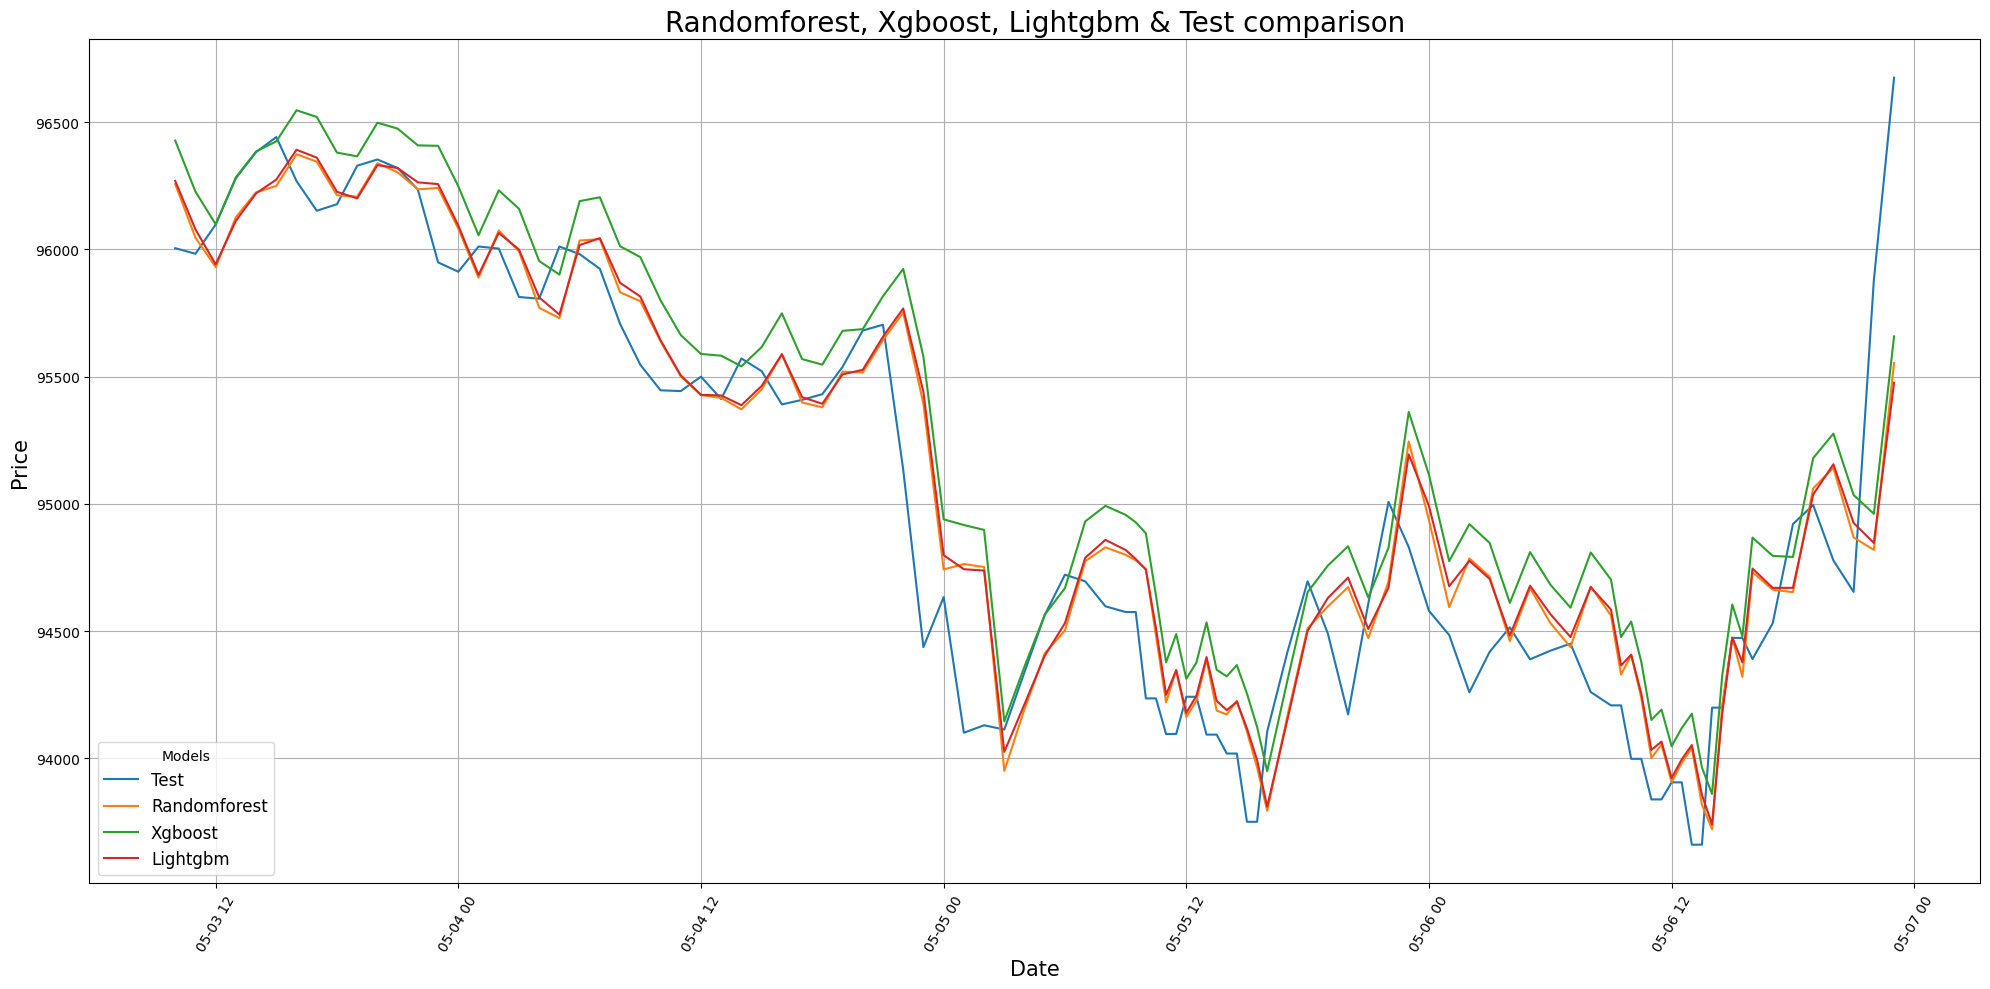

In [16]:
def make_plot(y, models=rf_hour, figsize: tuple=(14, 7)):
    """
    
    """
    if not isinstance(models, list): 
        models=[models]

    plt.figure(figsize=figsize)

    plt.plot(y.iloc[-models[0].test_size:][-100:], label='Test')

    for model in models:
        plt.plot(model.result_.y_pred[-100:], label=f'{model.model_type.capitalize()}')

    plt.title(f"{', '.join([model.model_type.capitalize() for model in models])} & Test comparison", fontsize=20)
    plt.ylabel('Price', fontsize=15)
    plt.xlabel('Date', fontsize=15)

    plt.xticks(rotation=60)

    plt.legend(title='Models', fontsize=12)
    plt.grid(True)


make_plot(y=y_hour, models=[rf_hour, xgb_hour, lgbm_hour], figsize=(20, 10))

In [20]:
minute = pd.read_csv('minute_df.csv',  parse_dates=['Datetime'], index_col=['Datetime'])

minute

,Datetime,AMD,ARKK_ETF,ARK_NextGen_Internet_ETF,AUD/USD,Adobe,Amazon,Apple,BTC,Bitcoin_Cash,Brent_Oil,Cardano,Chainlink,Copper,Dogecoin,Dow_Jones,ETH,EUR/USD,Ethereum_Classic,GBP/USD,Gold,Google,Intel,Invesco_QQQ,Litecoin,Marathon_Digital,Meta,MicroStrategy,Microsoft,NASDAQ_100,NVIDIA,Natural_Gas,Platinum,Riot_Blockchain,S&P_500,SPDR_Consumer_Discretionary,SPDR_Energy,SPDR_Financials,SPDR_HealthCare,SPDR_Industrials,SPDR_Materials,SPDR_RealEstate,SPDR_Tech,Silver,Stellar,TRON,Tesla,Tether,USD/CAD,USD/CHF,USD/JPY,VIX,VanEck_Semiconductor_ETF,WTI,XRP,iShares_Semiconductor_ETF,RSI,MACD,ATR,OBV,minute,hour,BTC_lag1,BTC_lag2,BTC_lag5,BTC_lag10,BTC_mean5,BTC_std10,SMA_50,EMA_100,TEMA_20,KAMA_20,HMA_10
0,2025-03-07 14:30:00,99.00,51.92,101.08,0.63,446.80,200.24,235.86,89008.39,391.27,70.88,0.87,16.92,4.73,0.20,42495.99,2184.16,1.09,20.74,1.29,2925.45,172.07,20.60,488.35,104.05,14.63,626.33,293.25,393.17,20049.48,111.86,4.18,971.43,7.99,5732.03,205.22,86.95,49.17,148.80,132.24,87.38,42.29,215.96,32.78,0.29,0.24,262.58,1.00,1.44,1.14,0.01,24.73,221.57,67.71,2.50,199.52,42.13,20.25,263.97,-2139336704.00,30,14,89057.83,89297.19,89709.16,90081.46,89305.31,303.23,89229.23,88846.64,89477.15,88903.96,89327.43
1,2025-03-07 14:35:00,98.93,51.75,100.95,0.63,448.08,200.12,237.08,89198.55,390.64,70.87,0.87,16.96,4.73,0.20,42466.00,2187.85,1.09,20.76,1.29,2928.10,172.00,20.73,488.34,104.08,14.79,626.01,295.41,393.01,20052.17,111.91,4.18,973.10,8.04,5732.03,204.86,87.30,49.00,148.73,132.13,87.48,42.33,215.95,32.91,0.29,0.24,264.46,1.00,1.44,1.14,0.01,24.76,221.33,67.69,2.51,199.29,48.66,10.66,269.56,-1609400320.00,35,14,89008.39,89057.83,89579.07,89961.79,89229.21,263.94,89228.92,88851.04,89372.37,88905.44,89201.12
2,2025-03-07 14:40:00,99.45,52.15,101.58,0.63,448.68,200.51,238.22,89970.20,391.55,70.91,0.87,17.03,4.73,0.20,42539.25,2207.13,1.09,20.81,1.29,2927.70,172.88,20.93,489.77,104.28,15.01,628.80,301.00,393.70,20121.80,112.21,4.19,973.40,8.13,5746.10,205.09,87.29,49.07,149.12,132.44,87.53,42.43,216.55,32.95,0.29,0.24,263.93,1.00,1.43,1.14,0.01,24.39,222.15,67.75,2.51,199.96,62.09,77.56,321.28,-1609400320.00,40,14,89198.55,89008.39,89584.09,89769.58,89306.43,299.48,89230.28,88856.25,89298.07,88906.57,89096.57
3,2025-03-07 14:45:00,99.35,52.42,102.16,0.63,448.79,200.67,238.78,90673.91,394.83,71.03,0.88,17.23,4.75,0.21,42684.04,2242.81,1.09,20.98,1.29,2928.25,173.11,20.95,490.83,104.78,15.22,629.98,306.02,394.07,20153.89,112.60,4.19,974.88,8.18,5760.66,205.77,87.48,49.22,149.51,132.91,87.71,42.48,217.12,32.98,0.30,0.25,264.64,1.00,1.43,1.14,0.01,24.11,222.81,67.88,2.55,200.42,66.62,164.94,347.01,988164096.00,45,14,89970.20,89198.55,89297.19,89411.57,89581.78,493.64,89248.10,88877.90,89454.33,88936.13,89233.78
4,2025-03-07 14:50:00,99.16,52.66,102.64,0.63,450.64,201.49,239.07,90917.13,395.38,71.00,0.89,17.39,4.77,0.21,42710.36,2243.44,1.09,21.08,1.29,2931.70,173.22,20.93,491.43,105.66,15.40,632.54,308.53,394.40,20187.42,113.04,4.19,975.90,8.22,5766.24,205.96,87.58,49.27,149.30,133.16,87.71,42.41,217.64,33.07,0.30,0.25,264.75,1.00,1.43,1.14,0.01,23.89,223.24,67.82,2.55,200.72,69.35,256.37,344.47,988164096.00,50,14,90673.91,89970.20,89057.83,89490.72,89953.64,652.81,89277.75,88913.52,89770.95,89012.62,89681.88
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
16787,2025-05-04 21:25:00,98.75,51.86,104.75,0.64,380.72,190.02,205.24,95697.96,358.18,61.44,0.69,14.14,4.66,0.17,41312.47,1834.47,1.13,16.07,1.33,3247.62,164.00,20.59,488.89,86.36,14.48,597.37,394.36,435.18,20098.55,114.36,3.67,966.88,8.38,5685.94,201.39,82.02,49.80,138.48,134.65,84.92,41.93,216.56,32.19,0.27,0.25,287.21,1.00,1.38,1.21,0.01,22.69,219.03,58.39,2.18,190.03,59.21,43.56,35.66,74372461568.00,25,21,95683.89,95653.20,95732.37,95697.99,95691.

In [24]:
y_hour

Datetime
2023-05-09 19:00:00   27645.01
2023-05-09 20:00:00   27674.33
2023-05-09 21:00:00   27624.09
2023-05-09 22:00:00   27590.63
2023-05-09 23:00:00   27641.35
                        ...   
2025-05-06 19:00:00   94995.39
2025-05-06 20:00:00   94777.69
2025-05-06 21:00:00   94653.81
2025-05-06 22:00:00   95878.42
2025-05-06 23:00:00   96675.51
Name: BTC, Length: 20955, dtype: float64

In [25]:
X_hour

,Apple,Cardano,Adobe,AMD,Amazon,ARKK_ETF,ARK_NextGen_Internet_ETF,AUD/USD,Bitcoin_Cash,Brent_Oil,USD/CHF,WTI,Dogecoin,Ethereum_Classic,ETH,EUR/USD,GBP/USD,Gold,Google,Copper,Intel,USD/JPY,Chainlink,Litecoin,Marathon_Digital,Meta,Microsoft,MicroStrategy,Natural_Gas,NVIDIA,Platinum,Invesco_QQQ,Riot_Blockchain,Silver,VanEck_Semiconductor_ETF,iShares_Semiconductor_ETF,TRON,Tesla,USD/CAD,Tether,SPDR_Materials,SPDR_Energy,SPDR_Financials,SPDR_Industrials,SPDR_Tech,Stellar,SPDR_RealEstate,SPDR_HealthCare,SPDR_Consumer_Discretionary,XRP,Dow_Jones,S&P_500,NASDAQ_100,VIX,RSI,MACD,ATR,OBV,day,hour,BTC_lag1,BTC_lag2,BTC_lag5,BTC_lag10,BTC_mean5,BTC_std10
Datetime,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2023-05-09 19:00:00,171.85,0.36,342.89,95.12,106.57,38.23,49.66,0.68,122.20,77.27,1.12,73.52,0.07,18.82,1844.70,1.10,1.26,2042.82,107.39,3.90,30.11,0.01,6.51,79.56,9.39,233.53,306.87,30.36,2.26,28.58,1115.08,321.59,11.45,25.88,123.07,136.45,0.07,168.99,1.34,1.00,78.75,80.41,32.28,99.38,150.01,0.09,37.07,132.46,147.65,0.42,33579.11,4120.83,13201.80,17.66,47.65,-25.82,162.64,-23447552.00,9,19,27648.51,27591.68,27551.23,27748.24,27553.37,89.80
2023-05-09 20:00:00,171.85,0.36,342.89,95.12,106.57,38.23,49.66,0.68,122.01,77.39,1.12,73.59,0.07,18.83,1849.06,1.10,1.26,2043.43,107.39,3.90,30.11,0.01,6.52,79.76,9.39,233.53,306.87,30.36,2.26,28.58,1115.80,321.59,11.45,25.89,123.07,136.45,0.07,168.99,1.34,1.00,78.75,80.41,32.28,99.38,150.01,0.09,37.07,132.46,147.65,0.42,33579.11,4120.83,13201.80,17.66,55.59,-16.54,162.01,-23447552.00,9,20,27592.72,27648.51,27466.98,27748.24,27588.98,74.88
2023-05-09 21:00:00,171.85,0.36,342.89,95.12,106.57,38.23,49.66,0.68,122.02,77.24,1.12,73.49,0.07,18.80,1850.68,1.10,1.26,2043.55,107.39,3.90,30.11,0.01,6.51,79.69,9.39,233.53,306.87,30.36,2.25,28.58,1119.82,321.59,11.45,25.92,123.07,136.45,0.07,168.99,1.34,1.00,78.75,80.41,32.28,99.38,150.01,0.09,37.07,132.46,147.65,0.43,33579.11,4120.83,13201.80,17.66,53.07,-11.64,160.75,-23447552.00,9,21,27645.01,27592.72,27466.98,27664.32,27630.45,76.12
2023-05-09 22:00:00,171.85,0.36,342.89,95.12,106.57,38.23,49.66,0.68,121.50,77.09,1.12,73.38,0.07,18.76,1845.12,1.10,1.26,2041.05,107.39,3.90,30.11,0.01,6.51,79.72,9.39,233.53,306.87,30.36,2.24,28.58,1119.20,321.59,11.45,25.86,123.07,136.45,0.07,168.99,1.34,1.00,78.75,80.41,32.28,99.38,150.01,0.09,37.07,132.46,147.65,0.43,33579.11,4120.83,13201.80,17.66,50.05,-10.84,151.55,-23447552.00,9,22,27674.33,27645.01,27591.68,27664.32,27636.93,72.45
2023-05-09 23:00:00,171.85,0.36,342.89,95.12,106.57,38.23,49.66,0.68,121.46,76.88,1.12,73.16,0.07,18.68,1844.05,1.10,1.26,2038.88,107.39,3.90,30.11,0.01,6.50,79.71,9.39,233.53,306.87,30.36,2.24,28.58,1117.90,321.59,11.45,25.84,123.07,136.45,0.07,168.99,1.34,1.00,78.75,80.41,32.28,99.38,150.01,0.09,37.07,132.46,147.65,0.43,33579.11,4120.83,13201.80,17.66,48.78,-11.42,143.93,-23447552.00,9,23,27624.09,27674.33,27648.51,27551.23,27625.36,71.71
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-05-06 19:00:00,198.84,0.66,383.40,98.89,185.20,48.87,102.12,0.65,358.54,62.42,1.22,59.40,0.17,15.83,1783.00,1.14,1.34,3403.70,163.42,4.78,19.95,0.01,13.54,83.45,13.16,587.88,433.89,385.76,3.55,113.75,992.73,481.97,7.87,33.34,215.99,186.97,0.25,275.56,1.38,1.00,83.76,80.60,49.21,133.54,213.90,0.26,41.61,134.28,197.57,2.14,40854.34,5611.74,19811.26,24.76,64.75,69.29,478.33,492165189120.00,6,19,94530.47,94389.95,94198.70,93904.98,94557.34,403.72
2025-05-06 20:00:00,198.84,0.66,383.40,98.89,185.20,48.87,102.12,0.65,360.75,62.53,1.22,59.55,0.17,15.90,1788.43,1.14,1.34,3403.92,163.42,4.79,19.95,0.01,13.63,84.28,13.16,587.88,433.89,385.76,3.55,113.75,992.32,481.97,7.87,33.37,215.99,186.97,0.25,275.56,1.38,1.00,83.76,80.60,49.21,133.54,213.90,0.26,41.61,134.28,197.57,2.14,4

In [28]:
from sklearn.base import BaseEstimator
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import RobustScaler
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from sklearn.model_selection import TimeSeriesSplit, RandomizedSearchCV
from sklearn.metrics import make_scorer
from sklearn.compose import TransformedTargetRegressor
import pandas as pd

def compute_metrics(
    y_true: np.ndarray,
    y_pred: np.ndarray,
    y_train: Optional[np.ndarray] = None,
) -> Dict[str, float]:
    """
    Compute metrics: MAE, RMSE, SMAPE, MASE (if y_train is provided).
    """
    mae_val = mean_absolute_error(y_true, y_pred)
    rmse_val = np.sqrt(mean_squared_error(y_true, y_pred))
    smape_val = smape(y_true, y_pred)

    if y_train is not None:
        mase_val = mase(y_true, y_pred, y_train)
    else:
        mase_val = None

    return {'mae': mae_val, 'rmse': rmse_val, 'smape': smape_val, 'mase': mase_val}


@dataclass
class ForecastResult:
    """
    Container for forecasting results: metrics, predictions, and model.
    """
    metrics: Dict[str, Dict[str, float]]
    y_pred: pd.Series
    model: Any

class TreeForecaster(BaseEstimator):
    """
    Forecaster with a single tree-based model: RandomForest, XGBoost, or LightGBM.

    :param str model_type: 'RandomForest', 'XGBoost', or 'LightGBM'
    :param int test_size:  number of last points for testing
    :param int cv_splits:  number of folds for TimeSeriesSplit
    :param int n_iter:     number of iterations for RandomizedSearchCV
    :param int seed:       random seed
    """
    def __init__(
        self,
        model_type: str = 'RandomForest',
        test_size: int = 260,
        cv_splits: int = 5,
        n_iter: int = 20,
        seed: int = 42
    ):
        allowed = {'RandomForest', 'XGBoost', 'LightGBM'}
        if model_type not in allowed:
            raise ValueError(f"model_type must be one of {allowed}")
        self.model_type = model_type
        self.test_size = test_size
        self.cv_splits = cv_splits
        self.n_iter = n_iter
        self.seed = seed

    def fit(self, X: pd.DataFrame, y: pd.Series):
        if len(X) <= self.test_size:
            raise ValueError(f"Not enough data ({len(X)}) for test_size={self.test_size}")

        # split data
        X_train, X_test = X.iloc[:-self.test_size], X.iloc[-self.test_size:]
        y_train, y_test = y.iloc[:-self.test_size], y.iloc[-self.test_size:]
        self.X_train, self.X_test = X_train, X_test

        # preprocess numeric features
        preprocessor = ColumnTransformer(
            transformers=[
                ('num', Pipeline([
                    ('imputer', SimpleImputer(strategy='mean')),
                    ('scaler', RobustScaler()),
                ]), X.select_dtypes(include='number').columns.tolist())
            ],
            remainder='drop'
        )

        # choose estimator
        estimators = {
            'RandomForest': RandomForestRegressor(random_state=self.seed),
            'XGBoost': XGBRegressor(random_state=self.seed, verbosity=0, n_jobs=-1),
            'LightGBM': LGBMRegressor(random_state=self.seed, n_jobs=-1)
        }
        estimator = estimators[self.model_type]

        # pipeline
        pipeline = Pipeline([
            ('prep', preprocessor),
            ('est', estimator)
        ])

        # wrap target
        model = TransformedTargetRegressor(
            regressor=pipeline,
            transformer=RobustScaler()
        )

        # hyperparameter distributions
        param_dist = {
            'RandomForest': {
                'regressor__est__n_estimators': randint(100, 500),
                'regressor__est__max_depth': randint(5, 50),
                'regressor__est__min_samples_leaf': randint(1, 20),
                'regressor__est__min_impurity_decrease': loguniform(1e-5, 1e-2),
                'regressor__est__bootstrap': [True],
                'regressor__est__max_samples': uniform(0.5, 0.5),
            },
            'XGBoost': {
                'regressor__est__eta': uniform(0.01, 0.29),
                'regressor__est__max_depth': randint(3, 11),
                'regressor__est__subsample': uniform(0.5, 0.5),
                'regressor__est__colsample_bytree': uniform(0.5, 0.5),
                'regressor__est__lambda': loguniform(1e-3, 10),
                'regressor__est__alpha': loguniform(1e-3, 10),
                'regressor__est__n_estimators': randint(100, 1000),
            },
            'LightGBM': {
                'regressor__est__learning_rate': uniform(0.01, 0.29),
                'regressor__est__num_leaves': randint(20, 150),
                'regressor__est__min_child_samples': randint(5, 100),
                'regressor__est__subsample': uniform(0.5, 0.5),
                'regressor__est__colsample_bytree': uniform(0.5, 0.5),
                'regressor__est__reg_alpha': loguniform(1e-3, 10),
                'regressor__est__reg_lambda': loguniform(1e-3, 10),
                'regressor__est__n_estimators': randint(100, 1000),
            }
        }

        # time series CV
        tscv = TimeSeriesSplit(n_splits=self.cv_splits)

        # randomized search
        rs = RandomizedSearchCV(
            estimator=model,
            param_distributions=param_dist[self.model_type],
            n_iter=self.n_iter,
            cv=tscv,
            scoring=make_scorer(smape, greater_is_better=False),
            random_state=self.seed,
            n_jobs=-1
        )
        rs.fit(X_train, y_train)
        self.model_ = rs

        # predictions & metrics
        self.y_pred_train = rs.predict(X_train)
        self.y_pred_test  = rs.predict(X_test)

        # compute metrics (using existing compute_metrics function)
        metrics = {
            'train': compute_metrics(y_train.values, y_train.values, self.y_pred_train),
            'test':  compute_metrics(y_train.values, y_test.values,  self.y_pred_test)
        }
        self.result_ = ForecastResult(metrics, pd.Series(self.y_pred_test, index=X_test.index), rs)
        return self

In [23]:
rf = TreeForecaster(
    test_size=int(X_hour.shape[0]*0.2),
    n_iter=30
)
rf.fit(X_hour, y_hour)

2025-05-09 23:13:29.657928: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1746821609.684320   19818 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1746821609.692865   19818 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-05-09 23:13:29.721740: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-05-09 23:13:29.812332: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: 

ValueError: Found input variables with inconsistent numbers of samples: [16764, 4191]

In [ ]:
xgb = TreeForecaster(
    model_type='XGBoost',
    test_size=int(X_hour.shape[0]*0.2),
    n_iter=30
)
xgb.fit(X_hour, y_hour)

print('XGB DONE')

lgbm = TreeForecaster(
    model_type='LightGBM',
    test_size=int(X_hour.shape[0]*0.2),
    n_iter=30
)
lgbm.fit(X_hour, y_hour)

print('LGBM DONE')